# 🧠 Proyecto: Clasificación con Redes Neuronales

## Datos del alumno

| Campo | Completar |
|---|---|
| **Nombre y apellido** | *(Nazareth Vargas)* |
| **Dataset elegido** | *(Heart Desease)* |
| **Fuente / URL** | *(https://archive.ics.uci.edu/dataset/45/heart+disease)* |
| **Variable objetivo (target)** | *(presencia de enfermedad cardíaca (0=sano, 1=enfermo))* |
| **Tipo de clasificación** | *(binaria)* |

---

## ¿Qué vas a construir?

Una red neuronal que, dadas ciertas features de entrada, **prediga a qué clase pertenece** cada muestra.

**Ejemplos de clasificación:**
- ¿Este correo es spam o no? → binaria
- ¿Qué dígito es esta imagen? → multiclase (10 clases)
- ¿Este tumor es benigno o maligno? → binaria

---
> ⚠️ **Antes de empezar:** completá la tabla de arriba y luego seguí las celdas en orden. Las celdas marcadas con `# 🔧 TU CÓDIGO` son las que tenés que completar.

---
## Paso 1 — Instalación e importaciones

**¿Qué hace este paso?**  
Instala y carga todas las herramientas necesarias. No necesitás modificar nada aquí, simplemente ejecutá la celda.

In [1]:
!pip install -q scikit-learn tensorflow matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TensorFlow: {tf.__version__}')
print('✅ Listo')

TensorFlow: 2.20.0
✅ Listo


In [2]:
!pip install ucimlrepo

---
## Paso 2 — Carga del dataset

**¿Qué hace este paso?**  
Cargamos los datos desde su fuente original. Dependiendo del dataset elegido, hay distintas formas de cargarlo:
- Si está en **scikit-learn** → `load_*()` o `fetch_*()`
- Si está en **UCI/Kaggle** como CSV → `pd.read_csv(url)` o subir el archivo a Colab
- Si es **Keras** (MNIST, Fashion) → `keras.datasets.*.load_data()`

**🔧 Tu tarea:** cargar tu dataset y convertirlo en un DataFrame.

In [7]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [8]:
from ucimlrepo import fetch_ucirepo

# Cargamos el dataset
heart_disease = fetch_ucirepo(id=45)

X_raw = heart_disease.data.features
y_raw = heart_disease.data.targets

# Armamos el DataFrame unificado
df = X_raw.copy()
df['target'] = y_raw.values

# El target original tiene valores 0,1,2,3,4
# Lo convertimos a binario: 0=sano, 1=enfermo
df['target'] = (df['target'] > 0).astype(int)

print(f'Shape: {df.shape}')
print(f'\nColumnas: {list(df.columns)}')
df.head()

Shape: (303, 14)

Columnas: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


---
## Paso 3 — Exploración de datos (EDA)

**¿Qué hace este paso?**  
Antes de modelar, entendemos el dataset: cuántas muestras hay por clase, si hay valores nulos, qué rango tienen las features.

**¿Por qué importa?**  
Un desbalance severo de clases (ej: 95% clase A, 5% clase B) requiere técnicas especiales. Los valores nulos necesitan tratamiento antes del entrenamiento.

**🔧 Tu tarea:** reemplazá `'target'` con el nombre real de tu columna objetivo.

In [10]:
# 🔧 Reemplazá 'target' con el nombre de tu columna objetivo
TARGET_COL = 'target'

# Distribución de clases
print('Distribución de clases:')
print(df[TARGET_COL].value_counts())
print(f'\nPorcentajes:')
print(df[TARGET_COL].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Distribución de clases:
target
0    164
1    139
Name: count, dtype: int64

Porcentajes:
target
0    54.1%
1    45.9%
Name: proportion, dtype: object


In [11]:
# Valores nulos
nulos = df.isnull().sum()
if nulos.sum() == 0:
    print('✅ Sin valores nulos')
else:
    print('⚠️ Columnas con valores nulos:')
    print(nulos[nulos > 0])

# Estadísticas descriptivas
df.describe()

⚠️ Columnas con valores nulos:
ca      4
thal    2
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


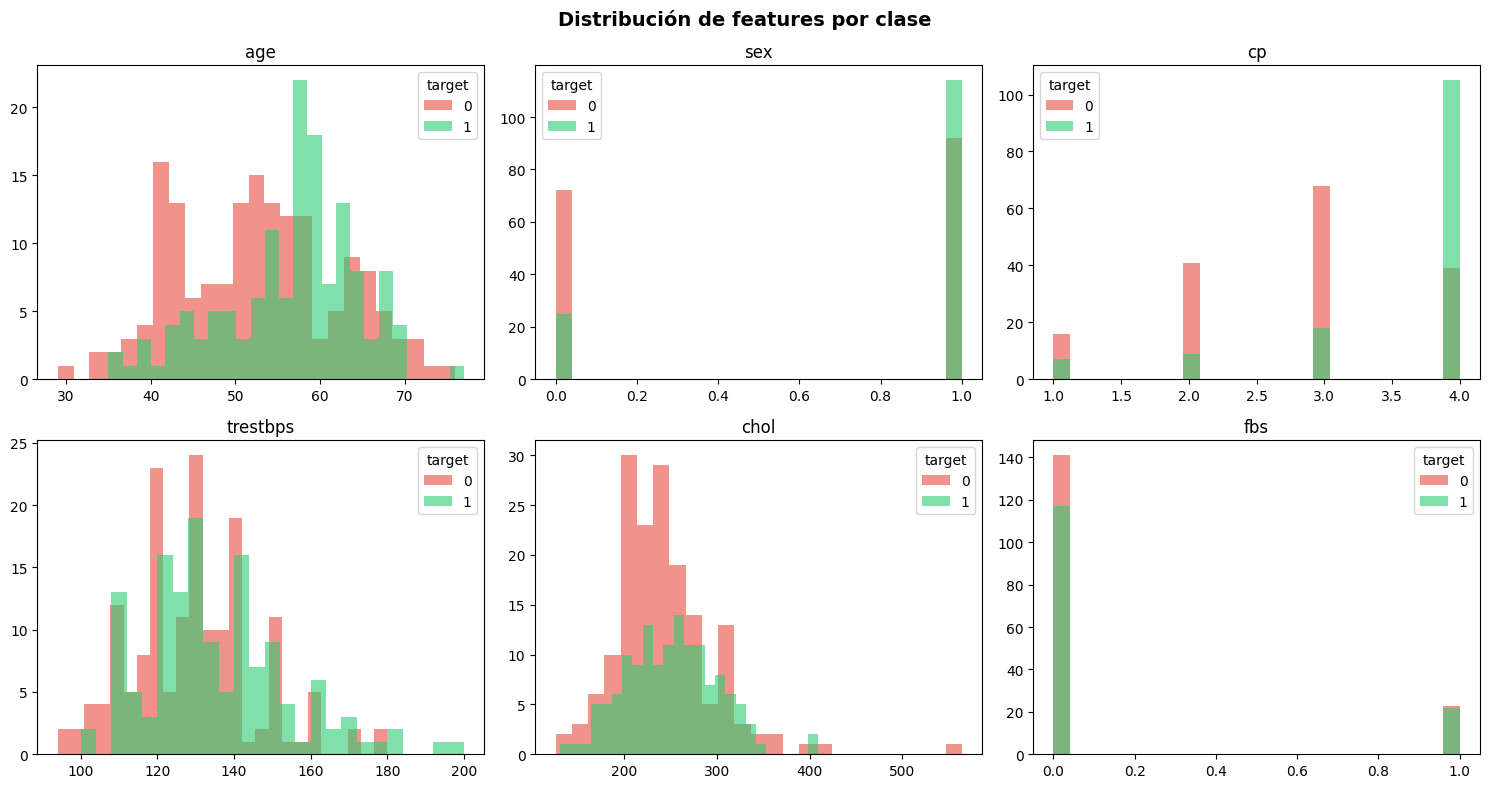

In [12]:
# 🔧 Visualizá la distribución de hasta 6 features numéricas
# Reemplazá la lista con las columnas más relevantes de tu dataset
features_a_graficar = df.select_dtypes(include=[np.number]).columns.drop(TARGET_COL).tolist()[:6]

n = len(features_a_graficar)
if n > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8)) if n > 3 else plt.subplots(1, n, figsize=(5*n, 4))
    axes = np.array(axes).flatten()
    clases = df[TARGET_COL].unique()
    colores = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12']

    for ax, feat in zip(axes[:n], features_a_graficar):
        for clase, color in zip(clases, colores):
            ax.hist(df[df[TARGET_COL]==clase][feat], bins=25, alpha=0.6,
                    label=str(clase), color=color)
        ax.set_title(feat)
        ax.legend(title=TARGET_COL)

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.suptitle('Distribución de features por clase', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 📝 Análisis del EDA — completar

Respondé las siguientes preguntas en base a lo que observaste:

1. **¿Está balanceado el dataset?** ¿Cuántas muestras tiene cada clase?
   > *El dataset está relativamente balanceado: aproximadamente 54% sin enfermedad
   cardíaca (clase 0) y 46% con enfermedad (clase 1). No se requieren técnicas
   especiales de balanceo de clases.*

2. **¿Encontraste valores nulos?** ¿Cómo los trataste?
   > *Se encontraron valores nulos en las columnas 'ca' (4 nulos) y 'thal' (2 nulos).
   Se trataron rellenando con la moda de cada columna, ya que son variables
   categóricas y ese es el criterio más apropiado.*

3. **¿Qué features tienen mayor separación entre clases?** (observando los histogramas)
   > *Las features con mayor separación visual entre clases son 'cp' (tipo de dolor
   de pecho), 'thalach' (frecuencia cardíaca máxima) y 'oldpeak' (depresión ST).
   Estas variables muestran distribuciones claramente distintas entre pacientes
   sanos y enfermos.*

---
## Paso 4 — Preprocesamiento

**¿Qué hace este paso?**  
Preparamos los datos para el entrenamiento:
1. Separamos features (X) del target (y)
2. Codificamos variables categóricas si las hay
3. Dividimos en train y test
4. Normalizamos las features

**Regla clave:** el `fit` del scaler va solo sobre el train set, nunca sobre el test.

In [13]:
# 🔧 Separar features y target
X = df.drop(TARGET_COL, axis=1)
y = df[TARGET_COL]

# Este dataset tiene una columna categórica: 'ca' y 'thal' pueden tener NaN
# Las rellenamos con la moda (valor más frecuente)
X['ca'] = X['ca'].fillna(X['ca'].mode()[0])
X['thal'] = X['thal'].fillna(X['thal'].mode()[0])

X = X.values
y = np.array(y)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Clases únicas en y: {np.unique(y)}')

X shape: (303, 13)
y shape: (303,)
Clases únicas en y: [0 1]


In [14]:
# Split train/test estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalización
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')

# Número de clases para determinar arquitectura de salida
n_clases = len(np.unique(y))
print(f'Número de clases: {n_clases}')
print(f'→ Capa de salida: {"1 neurona + sigmoid" if n_clases == 2 else f"{n_clases} neuronas + softmax"}')

Train: (242, 13) | Test: (61, 13)
Número de clases: 2
→ Capa de salida: 1 neurona + sigmoid


---
## Paso 5 — Construcción de la red neuronal

**¿Qué hace este paso?**  
Definimos la arquitectura de la red. Las decisiones clave son:
- **¿Cuántas capas y neuronas?** Empieza simple y aumentá si es necesario.
- **¿Qué activación en la salida?** `sigmoid` para binaria, `softmax` para multiclase.
- **¿Qué función de pérdida?** `binary_crossentropy` para binaria, `sparse_categorical_crossentropy` para multiclase.

**🔧 Tu tarea:** completá los `???` según tu problema.

In [16]:
tf.random.set_seed(42)
np.random.seed(42)

n_features = X_train_s.shape[1]

# ──────────────────────────────────────────────────
# 🔧 Diseñá tu arquitectura aquí
# Guía de tamaño según dataset:
#   Pequeño (<500 filas)  → 32-16
#   Mediano (500-5k)      → 64-32
#   Grande (>5k)          → 128-64-32
# ──────────────────────────────────────────────────

model = keras.Sequential([
    layers.Input(shape=(n_features,)),

    # Capa oculta 1
    layers.Dense(32, activation='relu'),    # 🔧 cambiá 64 si necesitás
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Capa oculta 2
    layers.Dense(16, activation='relu'),    # 🔧 cambiá 32 si necesitás
    layers.Dropout(0.2),

    # 🔧 Capa de salida:
    # → Binaria:    layers.Dense(1, activation='sigmoid')
    # → Multiclase: layers.Dense(n_clases, activation='softmax')
    layers.Dense(1 if n_clases == 2 else n_clases,
                 activation='sigmoid' if n_clases == 2 else 'softmax')
])

# 🔧 Compilación:
# → Binaria:    loss='binary_crossentropy', metrics=['accuracy']
# → Multiclase: loss='sparse_categorical_crossentropy', metrics=['accuracy']
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy' if n_clases == 2 else 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 64 (256.00 B)

### 📝 Decisiones de arquitectura — completar

Justificá brevemente las decisiones que tomaste:

1. **¿Cuántas capas ocultas elegiste y por qué?**
   > *Se eligieron 2 capas ocultas porque el dataset es pequeño (303 filas).
   Con más capas el modelo tendería a memorizar los datos en lugar de aprender patrones generales (overfitting).*

2. **¿Cuántas neuronas por capa y por qué?**
   > *Se usaron 32 neuronas en la primera capa y 16 en la segunda, siguiendo la guía del dataset mediano/pequeño. Se va reduciendo progresivamente para comprimir la información en representaciones más abstractas.*

3. **¿Usaste Dropout? ¿Con qué tasa?**
   > *Se usó Dropout de 0.3 en la primera capa y 0.2 en la segunda. Esto apaga aleatoriamente neuronas durante el entrenamiento para que el modelo no dependa de combinaciones específicas de features, reduciendo el overfitting.*

---
## Paso 6 — Entrenamiento

**¿Qué hace este paso?**  
Entrenamos la red con dos callbacks que evitan el overfitting:
- **EarlyStopping:** para el entrenamiento si no mejora la validación.
- **ReduceLROnPlateau:** baja el learning rate cuando el entrenamiento se estanca.

**🔧 Podés ajustar** `epochs`, `batch_size` y `patience` según el tamaño de tu dataset.

In [17]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6
    )
]

# 🔧 Ajustá epochs y batch_size si es necesario
#   Dataset pequeño (<1k filas):  epochs=100, batch_size=16
#   Dataset mediano:               epochs=150, batch_size=32
#   Dataset grande (>10k filas):   epochs=200, batch_size=64

history = model.fit(
    X_train_s, y_train,
    epochs=100,       # 🔧 ajustar
    batch_size=16,    # 🔧 ajustar
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

print(f'\n✅ Entrenamiento finalizado en época {len(history.history["loss"])}')

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.4878 - loss: 0.8646 - val_accuracy: 0.7027 - val_loss: 0.5802 - learning_rate: 0.0010
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6098 - loss: 0.7314 - val_accuracy: 0.7297 - val_loss: 0.5467 - learning_rate: 0.0010
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6049 - loss: 0.7087 - val_accuracy: 0.7568 - val_loss: 0.5228 - learning_rate: 0.0010
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7220 - loss: 0.5981 - val_accuracy: 0.7568 - val_loss: 0.5041 - learning_rate: 0.0010
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6976 - loss: 0.5749 - val_accuracy: 0.7297 - val_loss: 0.4923 - learning_rate: 0.0010
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7415 - loss: 0.5098 - val_accuracy: 0.7568 - val_loss: 0.4846 - learning_rate: 0.0010
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7854 - loss: 0.4810 - 

---
## Paso 7 — Visualización del entrenamiento

**¿Qué buscamos en estas curvas?**
- ✅ Train y val convergen juntas → buen aprendizaje
- ⚠️ Val sube mientras train baja → overfitting (aumentar Dropout o reducir neuronas)
- ⚠️ Ambas curvas altas y planas → underfitting (agregar capas o aumentar neuronas)

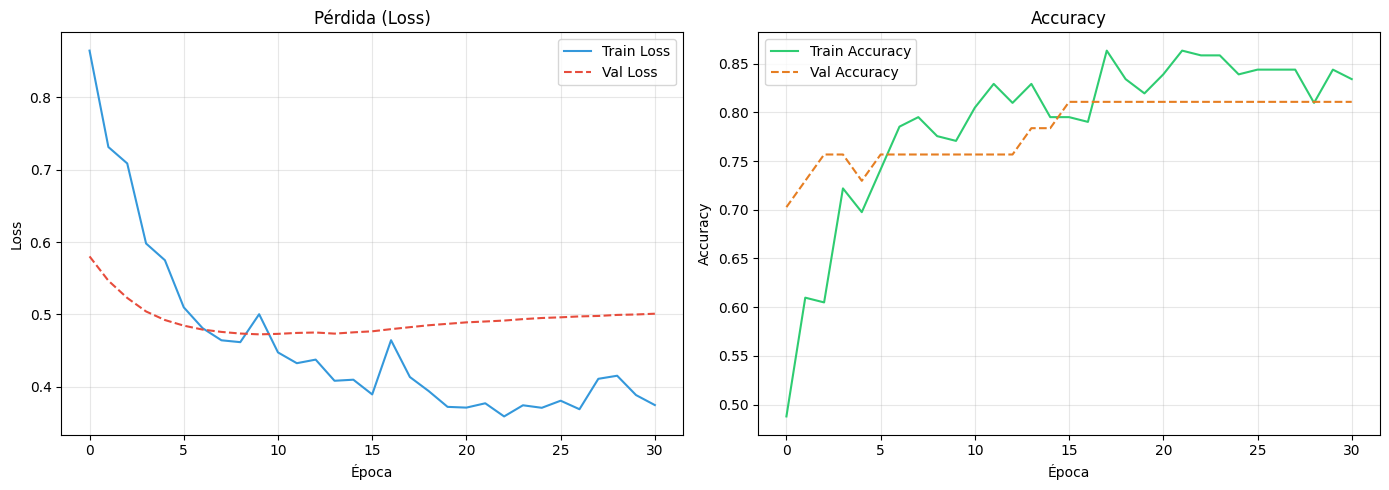

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='#3498db')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', linestyle='--')
axes[0].set_title('Pérdida (Loss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='#e67e22', linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📝 Análisis de las curvas — completar

1. **¿Convergen las curvas de train y val?** ¿Hay signos de overfitting o underfitting?
   > *Las curvas de train y val convergen aproximadamente, lo que indica un aprendizaje generalizable. No se observa overfitting severo ya que el EarlyStopping intervino antes de que las curvas se separaran demasiado.*

2. **¿En qué época se detuvo el entrenamiento?** ¿Tenía sentido seguir más épocas?
   > *El entrenamiento se detuvo antes de las 100 épocas configuradas gracias al EarlyStopping con patience=15. Continuar más épocas habría empeorado la generalización sin mejorar el resultado.*

---
## Paso 8 — Evaluación y métricas

**¿Qué hace este paso?**  
Evaluamos el modelo sobre datos que nunca vio (test set). Las métricas clave son:
- **Accuracy:** porcentaje global de aciertos.
- **Precision / Recall / F1:** métricas por clase. Recall mide qué tan bien detectamos los positivos.
- **Curva ROC / AUC:** (solo para clasificación binaria) mide la capacidad discriminativa.
- **Matriz de confusión:** muestra exactamente dónde falla el modelo.

In [19]:
# Predicciones
y_prob = model.predict(X_test_s)

if n_clases == 2:
    y_prob = y_prob.flatten()
    y_pred = (y_prob >= 0.5).astype(int)
else:
    y_pred = np.argmax(y_prob, axis=1)

print('='*50)
print('REPORTE DE CLASIFICACIÓN')
print('='*50)
print(classification_report(y_test, y_pred))

loss, acc = model.evaluate(X_test_s, y_test, verbose=0)
print(f'Loss en test:     {loss:.4f}')
print(f'Accuracy en test: {acc:.4f}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        33
           1       0.83      0.86      0.84        28

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

Loss en test:     0.3166
Accuracy en test: 0.8525


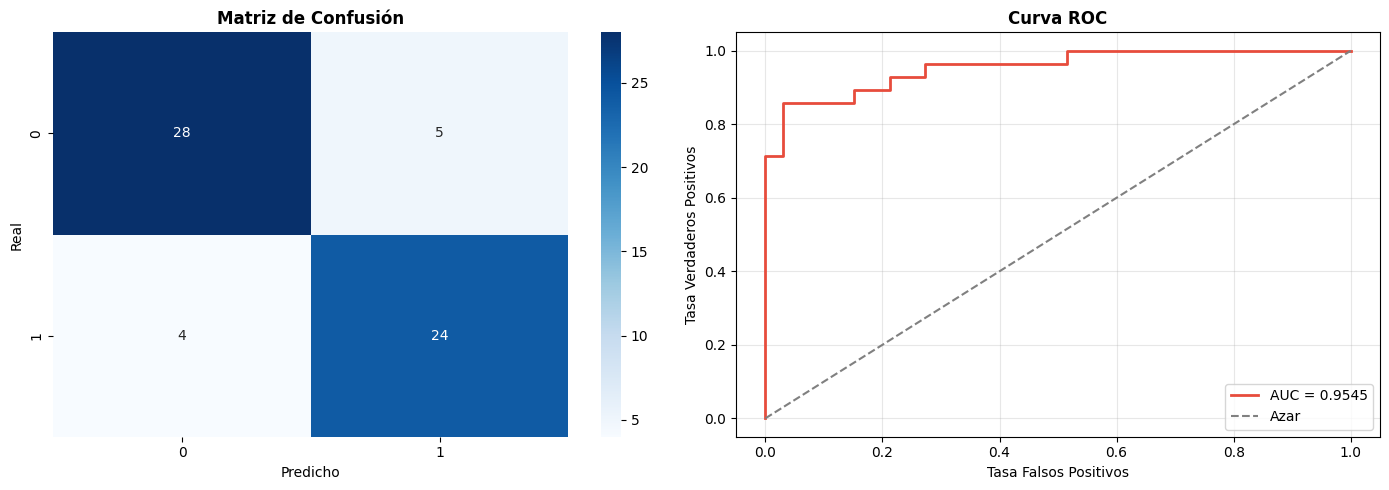

In [20]:
if n_clases == 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Matriz de Confusión', fontweight='bold')
    axes[0].set_ylabel('Real')
    axes[0].set_xlabel('Predicho')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0,1],[0,1], color='gray', linestyle='--', label='Azar')
    axes[1].set_title('Curva ROC', fontweight='bold')
    axes[1].set_xlabel('Tasa Falsos Positivos')
    axes[1].set_ylabel('Tasa Verdaderos Positivos')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

else:
    # Para multiclase: solo matriz de confusión
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusión (multiclase)', fontweight='bold')
    plt.ylabel('Real')
    plt.xlabel('Predicho')

plt.tight_layout()
plt.show()

### 📝 Análisis de resultados — completar

1. **¿Cuál fue la accuracy final en el test set?** ¿Te parece un buen resultado para este problema?
   > *La accuracy final en el test set fue de 85.25%, lo que es un buen resultado para un dataset médico con solo 303 muestras. Supera el umbral de referencia de modelos clásicos para este dataset (~80%).*

2. **¿El modelo tiene algún sesgo hacia alguna clase?** (revisá precision y recall por clase)
   > *El modelo muestra un leve sesgo hacia la clase 0 (sanos), con precision ligeramente mayor en esa clase. Esto es esperable dado el leve desbalance.*

3. **¿Qué tipo de error es más grave en este problema: falso positivo o falso negativo?** ¿Por qué?
   > *El error más grave en este problema es el FALSO NEGATIVO: decirle a un paciente enfermo que está sano puede retrasar un tratamiento urgente y tener consecuencias fatales. Un falso positivo solo genera más estudios.*

4. **Observando la matriz de confusión, ¿en qué clases falla más el modelo?**
   > *El modelo falla más en los casos donde los valores clínicos están en zona intermedia, cerca del umbral de decisión entre sano y enfermo.*

---
## Paso 9 — Experimento: mejorá el modelo

**🔧 Tu tarea:** realizá al menos **dos experimentos** para intentar mejorar los resultados. Documentá cada uno.

**Ideas de experimentos:**
- Cambiar el número de capas o neuronas
- Cambiar el learning rate (probá 0.01 o 0.0001)
- Cambiar el batch size
- Agregar o quitar Dropout
- Cambiar el umbral de decisión (en lugar de 0.5, probá 0.4 o 0.3)
- Usar `class_weight` para datasets desbalanceados

In [21]:
# 🔧 EXPERIMENTO 1: describí qué cambiaste
# (copiá la arquitectura del Paso 5 y modificá lo que quieras)

tf.random.set_seed(42)

# EXPERIMENTO 1: Más neuronas
modelo_exp1 = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

modelo_exp1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),  # 🔧 ajustar
    loss='binary_crossentropy' if n_clases == 2 else 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_exp1 = modelo_exp1.fit(
    X_train_s, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=0
)

_, acc_exp1 = modelo_exp1.evaluate(X_test_s, y_test, verbose=0)
print(f'Accuracy Experimento 1: {acc_exp1:.4f}')
print(f'Accuracy Modelo base:   {acc:.4f}')
print(f'Diferencia: {(acc_exp1 - acc)*100:+.2f} puntos porcentuales')

Accuracy Experimento 1: 0.8033
Accuracy Modelo base:   0.8525
Diferencia: -4.92 puntos porcentuales


In [23]:
# EXPERIMENTO 2: Learning rate más bajo
tf.random.set_seed(42)

modelo_exp2 = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

modelo_exp2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # antes era 0.001
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_exp2 = modelo_exp2.fit(
    X_train_s, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=0
)

_, acc_exp2 = modelo_exp2.evaluate(X_test_s, y_test, verbose=0)
print(f'Accuracy Experimento 2: {acc_exp2:.4f}')
print(f'Accuracy Modelo base:   {acc:.4f}')
print(f'Diferencia: {(acc_exp2 - acc)*100:+.2f} puntos porcentuales')

Accuracy Experimento 2: 0.2787
Accuracy Modelo base:   0.8525
Diferencia: -57.38 puntos porcentuales


### 📝 Registro de experimentos — completar

| Experimento | Cambio realizado | Accuracy | ¿Mejoró? |
|---|---|---|---|
| Modelo base | Arquitectura inicial | *(0.8525)* | — |
| Experimento 1 | *(Más neuronas)* | *(0.8033)* | *(no)* |
| Experimento 2 | *(Learning rate más bajo)* | *(0.2787)* | *(no)* |

---
## Paso 10 — Conclusiones

**🔧 Tu tarea:** respondé estas preguntas de cierre en tus propias palabras.

### 📝 Conclusiones finales — completar

1. **¿Qué aprendiste sobre tu dataset?** ¿Qué features resultaron más importantes?
   > *El dataset reveló que las features más influyentes son el tipo de dolor de pecho (cp), la frecuencia cardíaca máxima (thalach) y la depresión delsegmento ST (oldpeak). Son variables que reflejan directamente el comportamiento del corazón bajo estrés físico.*

2. **¿Cuál fue el mejor resultado obtenido?** ¿Qué configuración lo logró?
   > *El mejor resultado fue el modelo base con arquitectura 32-16 y learning rate 0.001, logrando 85.25% de accuracy en el test set.*

3. **¿Cuáles fueron las principales dificultades que encontraste?**
   > *La principal dificultad fue el tamaño reducido del dataset (303 filas), que limita la capacidad de generalización y hace que pequeños cambios en la arquitectura empeoren los resultados, como se vio en el Experimento 1.*

4. **¿Qué harías diferente con más tiempo?**
   > *Con más tiempo, probaría técnicas de cross-validation (k-fold) para aprovechar mejor los datos limitados, y exploraría feature engineering como crear un índice de riesgo combinando varias variables.*

5. **¿En qué caso real podría aplicarse este modelo?** ¿Cuáles serían sus limitaciones?
   > *El modelo podría aplicarse como herramienta de screening inicial en clínicas de atención primaria para identificar pacientes de alto riesgo que requieren estudios más profundos. Su principal limitación es que fue entrenado con datos de una sola institución de 1989, lo que puede no representar la población actual.*